In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import precision_score, recall_score
import numpy as np

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ",device)

Using device:  cuda


In [20]:
!nvidia-smi -i 6

Thu Apr  9 22:09:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.124.06             Driver Version: 570.124.06     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   6  NVIDIA A100-PCIE-40GB          Off |   00000000:B2:00.0 Off |                    0 |
| N/A   35C    P0            120W /  250W |   30487MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [15]:
import torch

gpu_count = torch.cuda.device_count()
print("Number of GPUs available:", gpu_count)

for i in range(gpu_count):
    props = torch.cuda.get_device_properties(i)
    total_mem_gb = props.total_memory / (1024 ** 3)
    
    print(f"\nGPU {i}")
    print("Name:", props.name)
    print("Total Memory:", round(total_mem_gb, 2), "GB")
    print("Allocated:", round(torch.cuda.memory_allocated(i) / (1024 ** 3), 2), "GB")
    print("Reserved:", round(torch.cuda.memory_reserved(i) / (1024 ** 3), 2), "GB")

Number of GPUs available: 7

GPU 0
Name: NVIDIA A100-PCIE-40GB
Total Memory: 39.49 GB
Allocated: 0.0 GB
Reserved: 0.0 GB

GPU 1
Name: NVIDIA A100-PCIE-40GB
Total Memory: 39.49 GB
Allocated: 0.0 GB
Reserved: 0.0 GB

GPU 2
Name: NVIDIA A100-PCIE-40GB
Total Memory: 39.49 GB
Allocated: 0.0 GB
Reserved: 0.0 GB

GPU 3
Name: NVIDIA A100-PCIE-40GB
Total Memory: 39.49 GB
Allocated: 0.0 GB
Reserved: 0.0 GB

GPU 4
Name: Tesla V100-PCIE-32GB
Total Memory: 31.73 GB
Allocated: 0.0 GB
Reserved: 0.0 GB

GPU 5
Name: Tesla V100-PCIE-32GB
Total Memory: 31.73 GB
Allocated: 0.0 GB
Reserved: 0.0 GB

GPU 6
Name: Tesla V100-PCIE-32GB
Total Memory: 31.73 GB
Allocated: 0.0 GB
Reserved: 0.0 GB


In [22]:
import torch

print("Current device index:", torch.cuda.current_device())
print("Current device name:", torch.cuda.get_device_name(torch.cuda.current_device()))
print("Device variable:", device)

Current device index: 5
Current device name: Tesla V100-PCIE-32GB
Device variable: cuda:5


In [21]:
import torch

torch.cuda.set_device(5)
device = torch.device("cuda:5")

print("Current device index:", torch.cuda.current_device())
print("Current device name:", torch.cuda.get_device_name(5))

Current device index: 5
Current device name: Tesla V100-PCIE-32GB


In [24]:
import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

In [25]:
# Use full 50k training set exactly as in the paper
import torchvision
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform
)

# Use standard 10k test set
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(testset)}")

Files already downloaded and verified
Files already downloaded and verified
Training samples: 50000
Test samples: 10000


In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Basic residual block
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()

        # Option A identity shortcut for CIFAR paper
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class ResNet_CIFAR(nn.Module):
    def __init__(self, block, n=5, num_classes=10):
        super(ResNet_CIFAR, self).__init__()

        self.in_channels = 16

        self.conv1 = nn.Conv2d(
            3, 16,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(16)

        # 3 stages
        self.layer1 = self._make_layer(block, 16, n, stride=1)
        self.layer2 = self._make_layer(block, 32, n, stride=2)
        self.layer3 = self._make_layer(block, 64, n, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride):
        strides = [stride] + [1] * (blocks - 1)
        layers = []

        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels

        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


def ResNet32():
    return ResNet_CIFAR(BasicBlock, n=5)

In [27]:
# -----------------------------
# Print Number of Parameters
# -----------------------------
model = ResNet32().to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")
print(f"In Millions          : {total_params / 1e6:.3f} M")

Total Parameters     : 466,906
Trainable Parameters : 466,906
In Millions          : 0.467 M


In [28]:
# Store history
history = {
    "Epoch": [],
    "Train Loss": [],
    "Train Accuracy": [],
    "Test Loss": [],
    "Test Accuracy": [],
    "Learning Rate": []
}

In [29]:
# -----------------------------
# Training Loop
# -----------------------------
model = ResNet32().to(device)
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[82, 123],
    gamma=0.1
)

num_epochs = 164

def evaluate(loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            total_loss += loss.item()

            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    acc = 100. * correct / total
    avg_loss = total_loss / len(loader)

    return avg_loss, acc


for epoch in range(num_epochs):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total

    #test_loss, test_acc = evaluate(test_loader)

    scheduler.step()
    # Store history
    history["Epoch"].append(epoch + 1)
    history["Train Accuracy"].append(train_acc)
    history["Train Loss"].append(train_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f} | "
          f"Train Acc: {train_acc:.2f}% ")

Epoch [1/164] | Train Loss: 1.8183 | Train Acc: 30.74% 
Epoch [2/164] | Train Loss: 1.3300 | Train Acc: 51.51% 
Epoch [3/164] | Train Loss: 1.0293 | Train Acc: 63.11% 
Epoch [4/164] | Train Loss: 0.8321 | Train Acc: 70.84% 
Epoch [5/164] | Train Loss: 0.7195 | Train Acc: 74.74% 
Epoch [6/164] | Train Loss: 0.6334 | Train Acc: 77.88% 
Epoch [7/164] | Train Loss: 0.5736 | Train Acc: 80.05% 
Epoch [8/164] | Train Loss: 0.5292 | Train Acc: 81.73% 
Epoch [9/164] | Train Loss: 0.4952 | Train Acc: 83.00% 
Epoch [10/164] | Train Loss: 0.4659 | Train Acc: 83.72% 
Epoch [11/164] | Train Loss: 0.4407 | Train Acc: 84.70% 
Epoch [12/164] | Train Loss: 0.4199 | Train Acc: 85.56% 
Epoch [13/164] | Train Loss: 0.4038 | Train Acc: 86.08% 
Epoch [14/164] | Train Loss: 0.3874 | Train Acc: 86.63% 
Epoch [15/164] | Train Loss: 0.3708 | Train Acc: 87.17% 
Epoch [16/164] | Train Loss: 0.3612 | Train Acc: 87.55% 
Epoch [17/164] | Train Loss: 0.3503 | Train Acc: 87.92% 
Epoch [18/164] | Train Loss: 0.3388 | Tr

In [32]:
import pandas as pd

# Convert dictionary to DataFrame
history_df = pd.DataFrame(history)

# Save to Excel file
history_df.to_excel("resnet32_training_history.xlsx", index=False)

print("Training history saved successfully as 'resnet32_training_history.xlsx'")

ValueError: arrays must all be same length

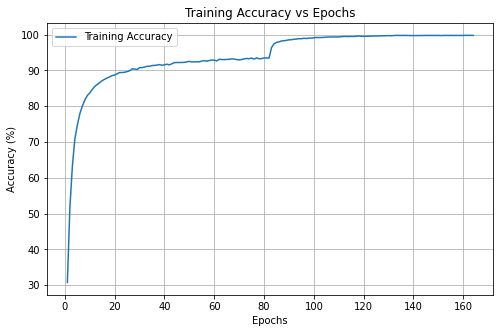

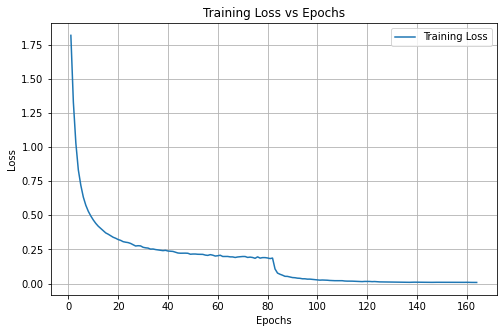

In [31]:
import matplotlib.pyplot as plt

epochs = history["Epoch"]

# Accuracy Curve
plt.figure(figsize=(8,5))
plt.plot(epochs, history["Train Accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

# Loss Curve
plt.figure(figsize=(8,5))
plt.plot(epochs, history["Train Loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
# -----------------------------
# Final Test Evaluation
# -----------------------------
test_loss, test_acc = evaluate(test_loader)

# Classification error (same as paper)
test_error = 100 - test_acc

# Precision & Recall
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = outputs.max(1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.numpy())

precision = precision_score(all_targets, all_preds, average='macro')
recall = recall_score(all_targets, all_preds, average='macro')

print("\n===== Final Test Metrics (Paper Style) =====")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Test Error: {test_error:.2f}%")
print(f"Test Precision (Macro): {precision:.4f}")
print(f"Test Recall (Macro): {recall:.4f}")


===== Final Test Metrics (Paper Style) =====
Test Loss: 0.3390
Test Accuracy: 92.51%
Test Error: 7.49%
Test Precision (Macro): 0.9250
Test Recall (Macro): 0.9251
